# 🎗️ Breast Cancer (Wisconsin) Dataset — EDA & Predictive Modelling

**Goal**: Understand the data through Exploratory Data Analysis (EDA), then build the **best predictive model** for classifying breast cancer as **Malignant (M)** or **Benign (B)** using robust cross-validation and hyperparameter tuning, wrapped in a clean scikit-learn `Pipeline`.

---

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

print('Setup complete.')

Setup complete.


## 2. Load the Data

In [2]:
# Load the dataset
data_path = 'breast-cancer.csv'
df = pd.read_csv(data_path)

print('Shape:', df.shape)
df.head()

Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [5]:
# Check for missing values and duplicates
print('Missing values:', df.isnull().sum().sum())
print('Duplicated rows:', df.duplicated().sum())
print('\nDiagnosis counts:')
print(df['diagnosis'].value_counts())
print('\nDiagnosis %:')
print((df['diagnosis'].value_counts(normalize=True) * 100).round(2))

Missing values: 0
Duplicated rows: 0

Diagnosis counts:
diagnosis
B    357
M    212
Name: count, dtype: int64

Diagnosis %:
diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Distribution

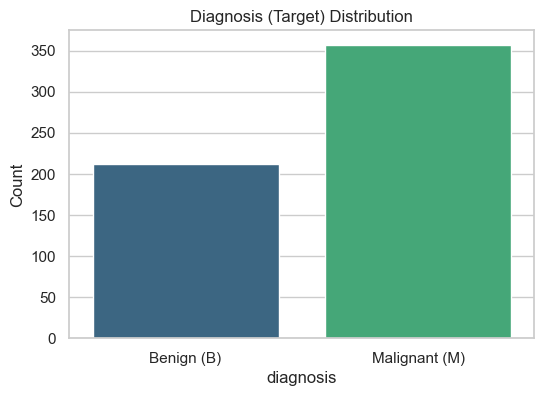

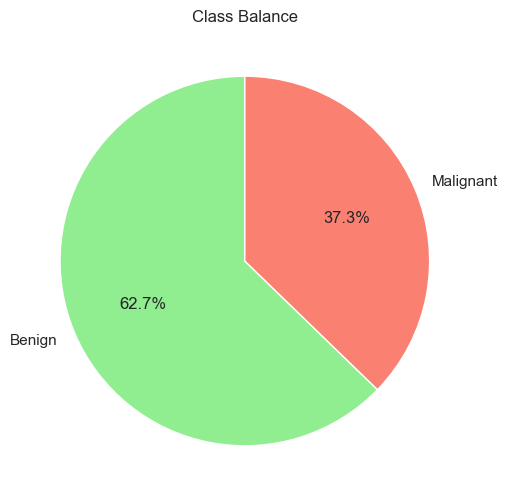

In [6]:
# Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df, palette='viridis')
plt.xticks([0, 1], ['Benign (B)', 'Malignant (M)'])
plt.title('Diagnosis (Target) Distribution')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6, 6))
df['diagnosis'].value_counts().plot.pie(
    autopct='%1.1f%%', labels=['Benign', 'Malignant'],
    colors=['lightgreen', 'salmon'], startangle=90
)
plt.title('Class Balance')
plt.ylabel('')
plt.show()

### 3.2 Feature Groups

The 30 features are grouped into three sets of measurements:
- **mean** — average of each cell nucleus measurement
- **se** — standard error of each measurement
- **worst** — worst (largest) value of each measurement

Each group measures 10 underlying attributes (radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension).

In [7]:
# Group features by measurement type
mean_cols  = [c for c in df.columns if c.endswith('_mean')]
se_cols    = [c for c in df.columns if c.endswith('_se')]
worst_cols = [c for c in df.columns if c.endswith('_worst')]

print(f'Mean features: {len(mean_cols)}')
print(f'SE features:   {len(se_cols)}')
print(f'Worst features:{len(worst_cols)}')
print(f'\nExample (mean): {mean_cols}')

Mean features: 10
SE features:   10
Worst features:10

Example (mean): ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']


### 3.3 Distribution of Key Mean Features by Diagnosis

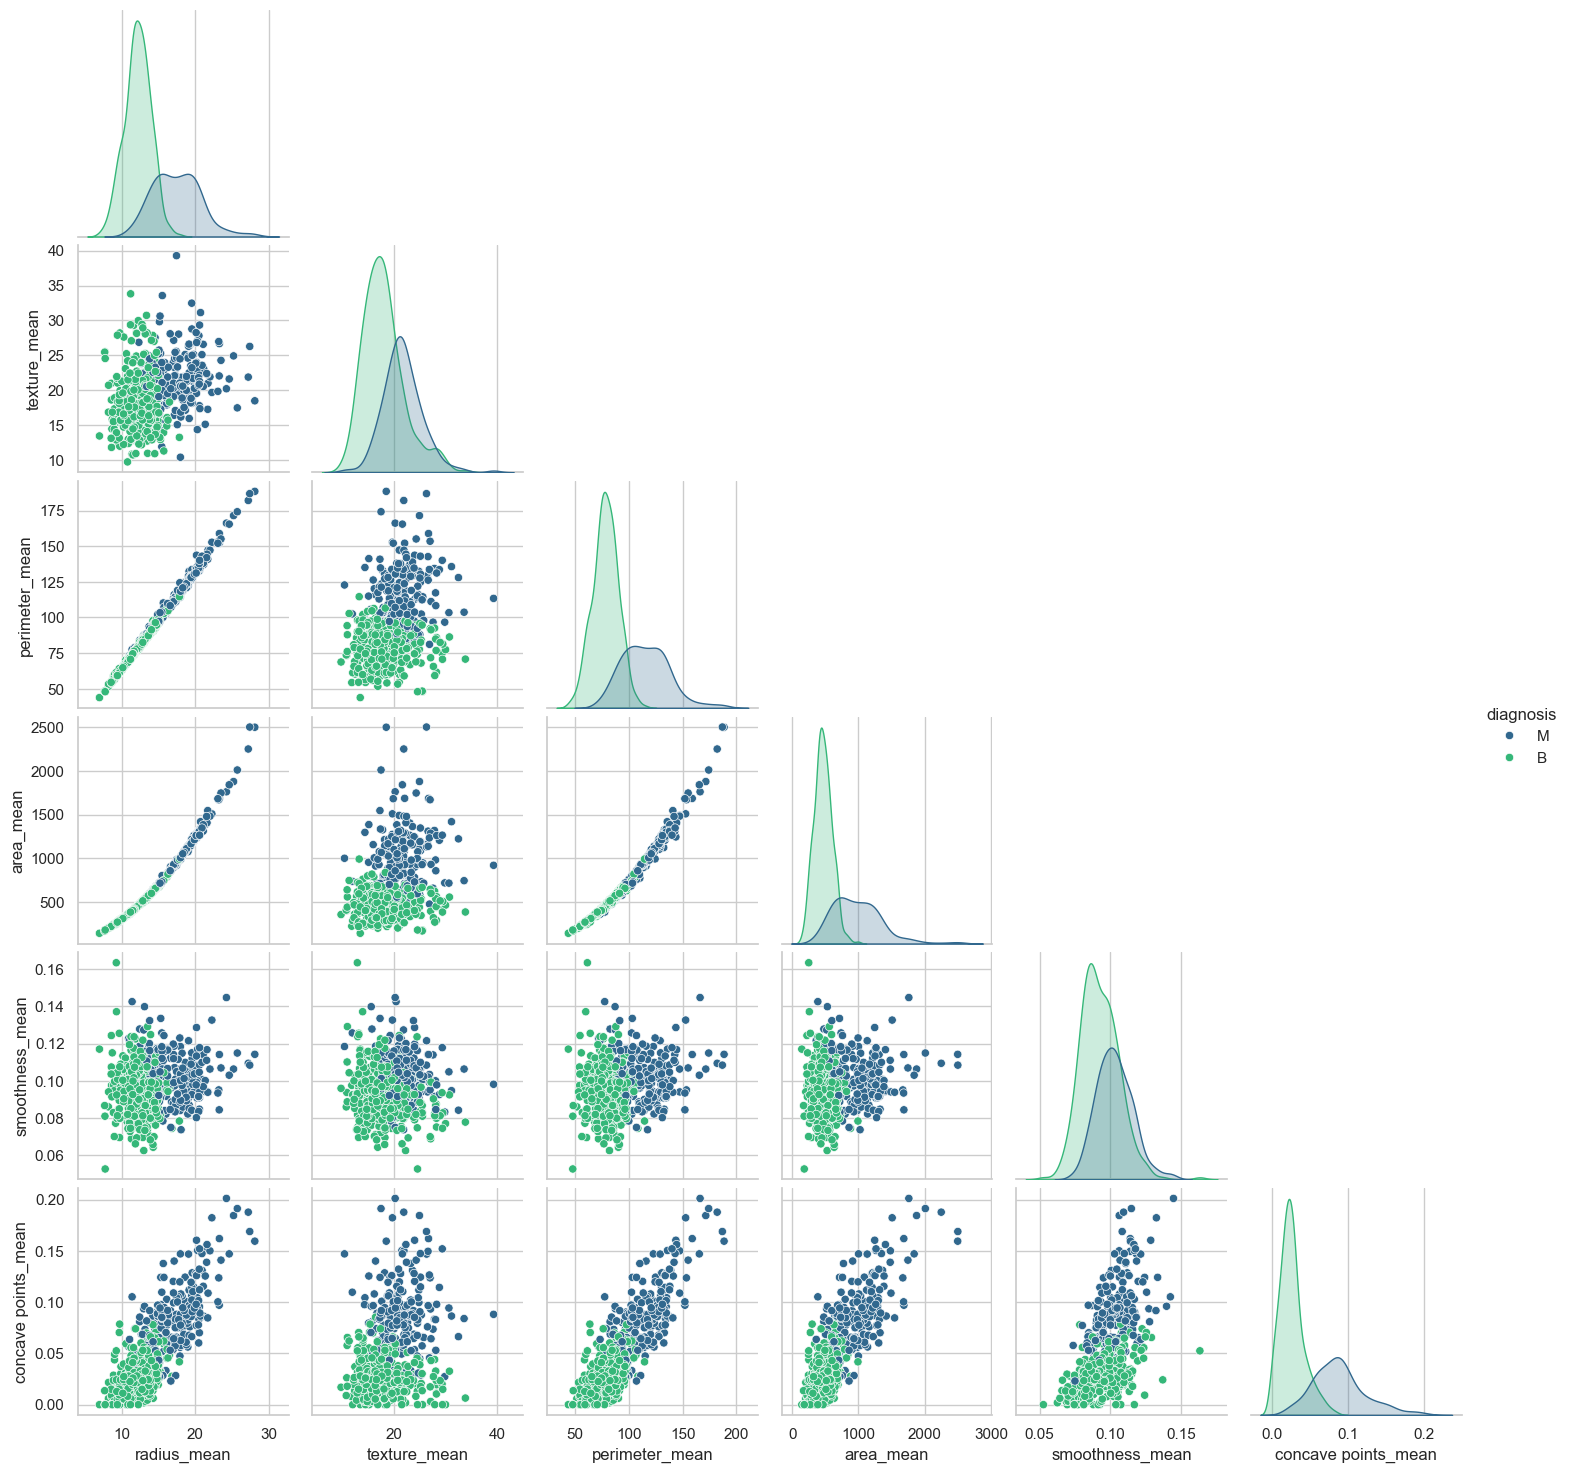

In [8]:
# Pairplot of the most discriminative mean features
key_feats = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
             'smoothness_mean', 'concave points_mean', 'diagnosis']
sns.pairplot(df[key_feats], hue='diagnosis', corner=True, palette='viridis')
plt.show()

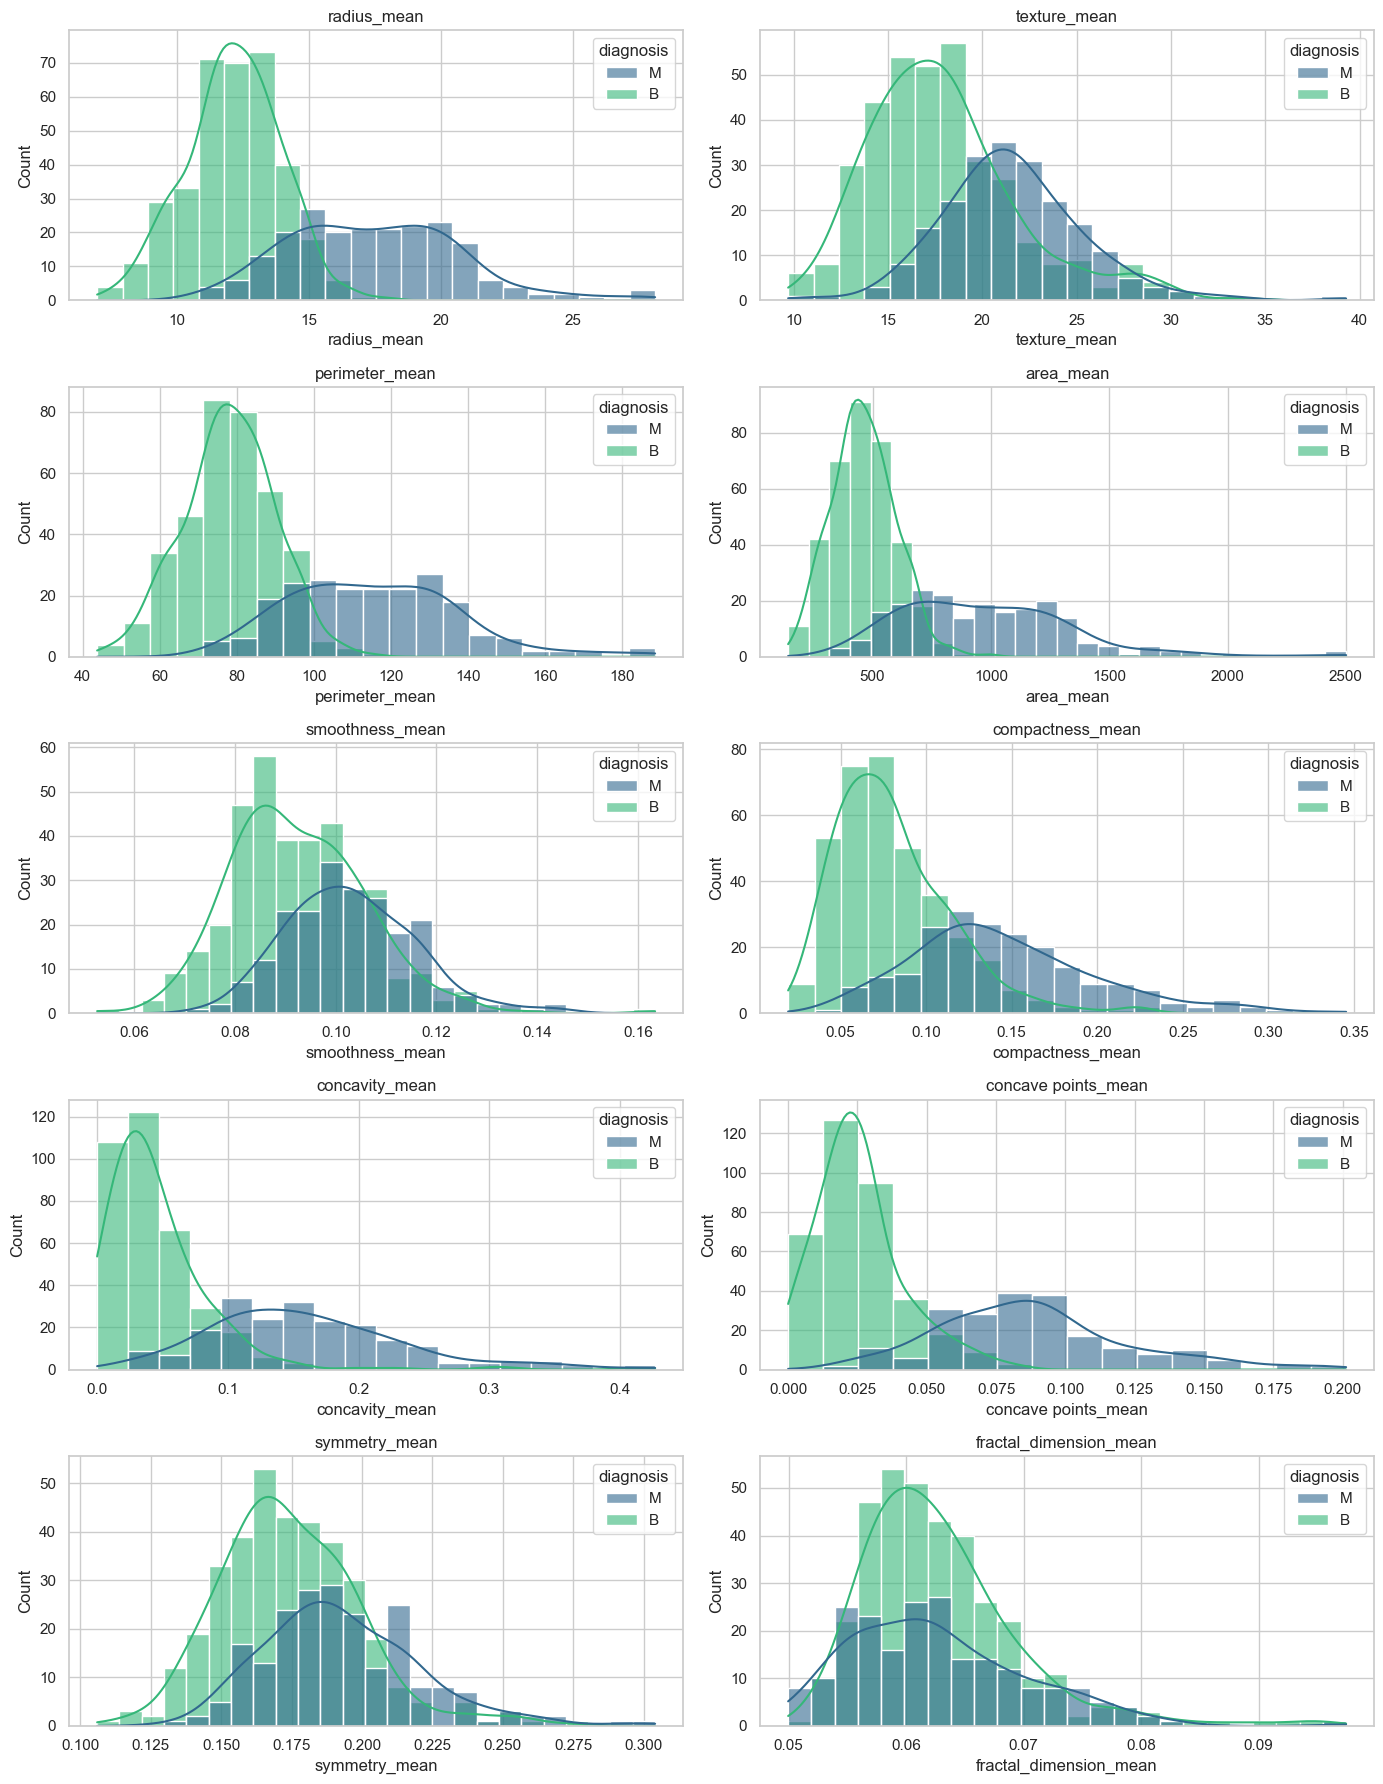

In [9]:
# Distribution comparison: Malignant vs Benign (mean features)
fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()
for i, col in enumerate(mean_cols):
    sns.histplot(data=df, x=col, hue='diagnosis', kde=True,
                 ax=axes[i], palette='viridis', alpha=0.6)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### 3.4 Boxplots — Outlier Analysis (mean features)

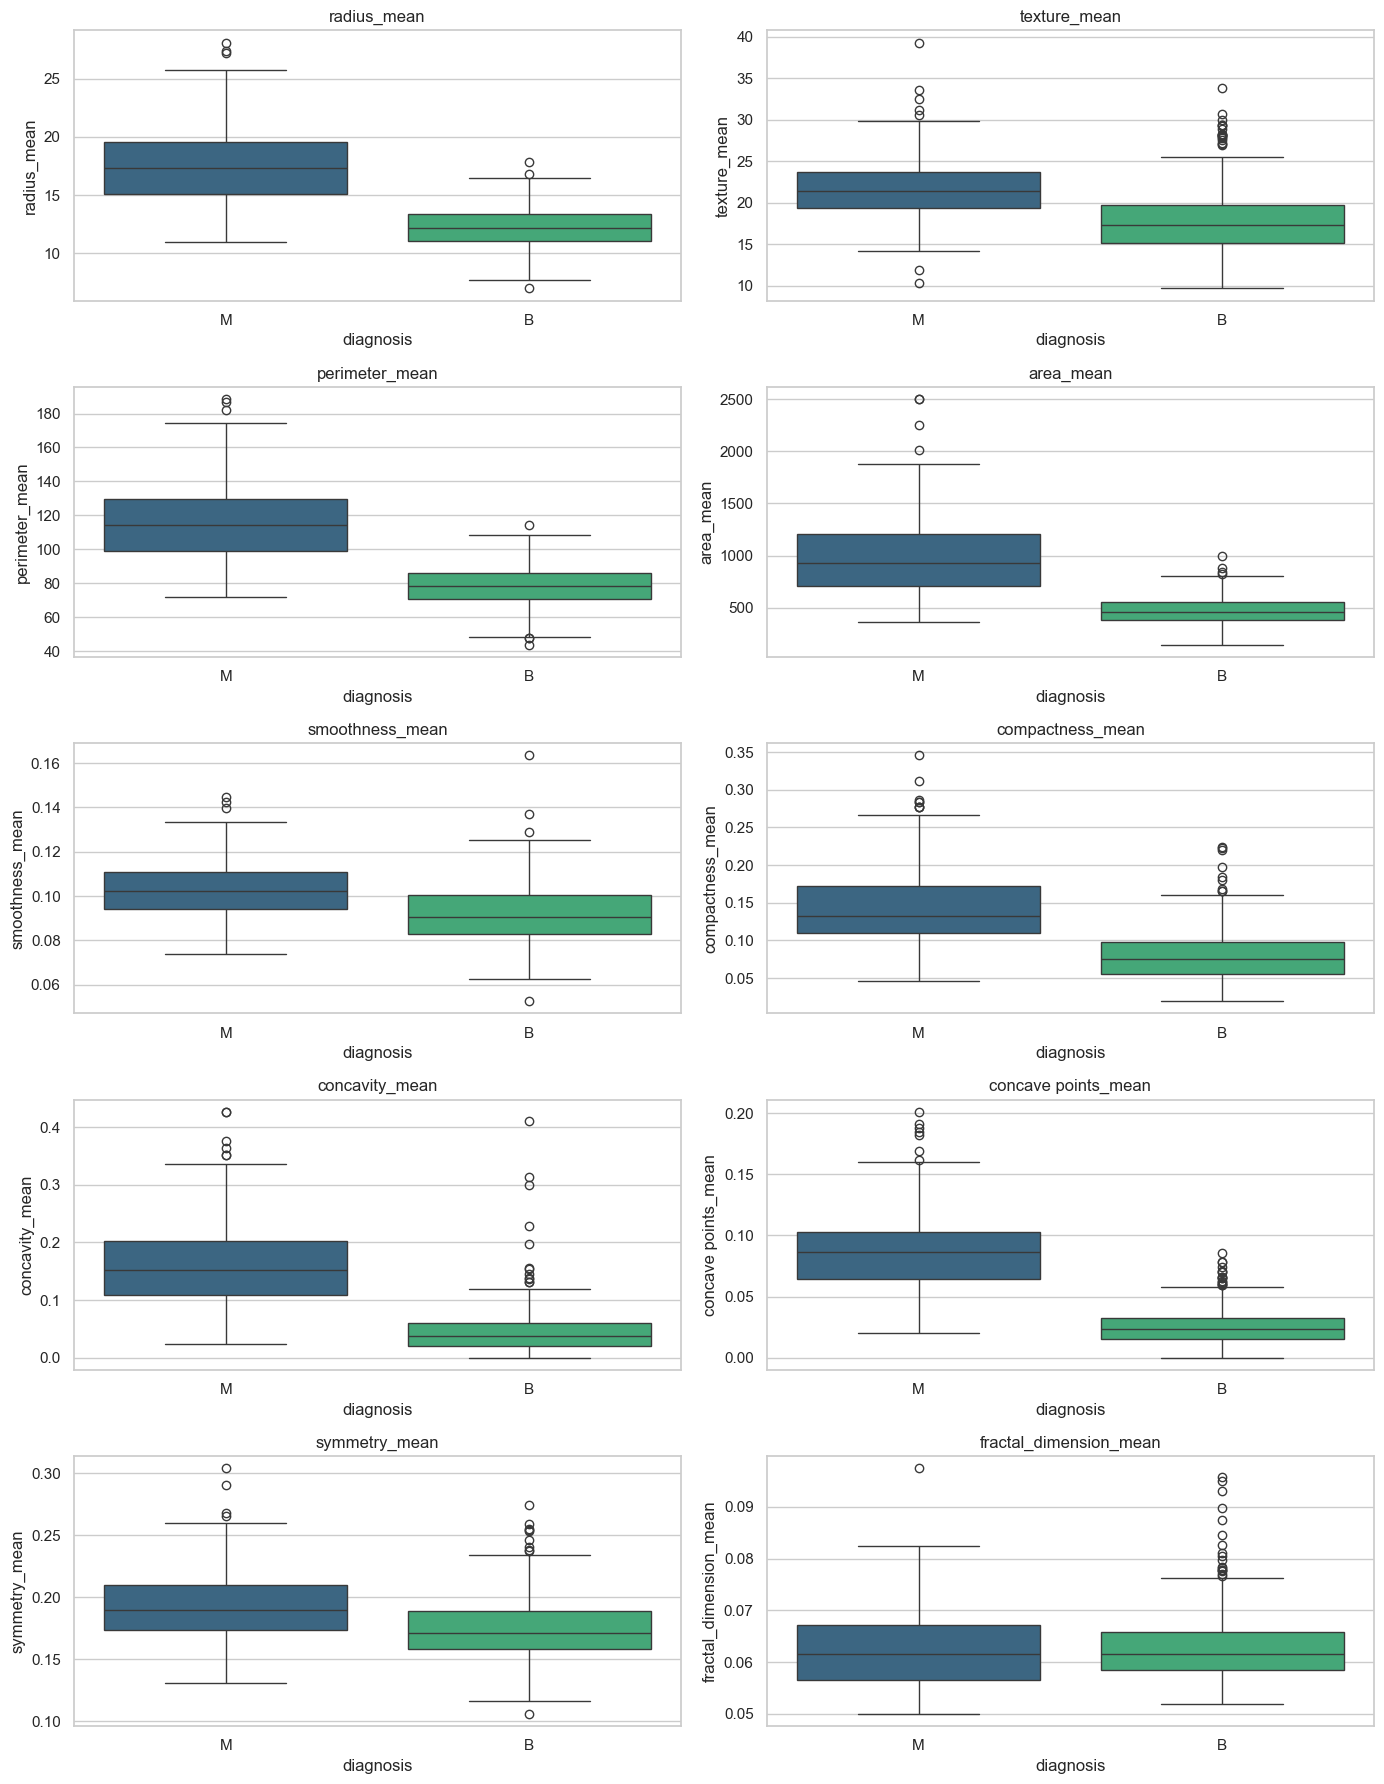

In [10]:
# Boxplots by diagnosis for mean features
fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()
for i, col in enumerate(mean_cols):
    sns.boxplot(x='diagnosis', y=col, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### 3.5 Correlation Analysis

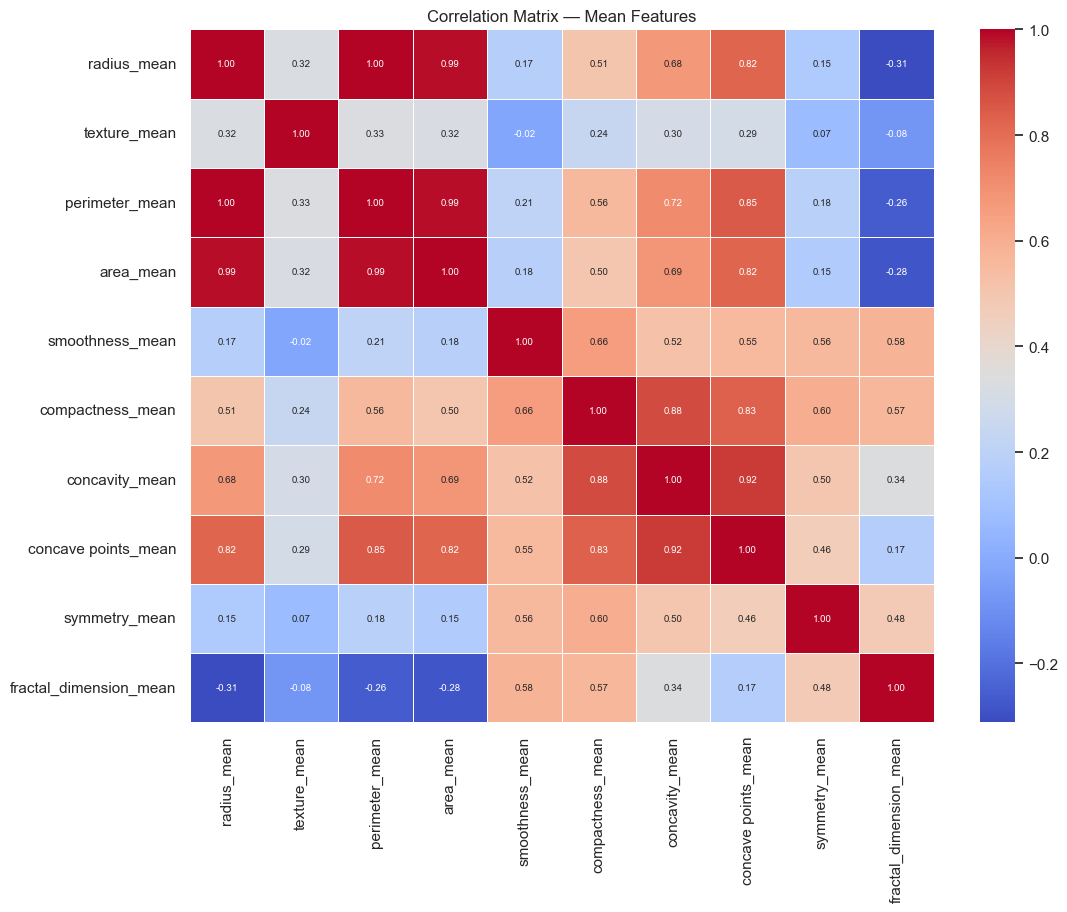

In [11]:
# Correlation matrix (mean features only to reduce clutter)
corr_mean = df[mean_cols].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr_mean, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Matrix — Mean Features')
plt.show()

Top 10 features most correlated with Malignant:
concave points_worst    0.794
perimeter_worst         0.783
concave points_mean     0.777
radius_worst            0.776
perimeter_mean          0.743
area_worst              0.734
radius_mean             0.730
area_mean               0.709
concavity_mean          0.696
concavity_worst         0.660
Name: diagnosis, dtype: float64


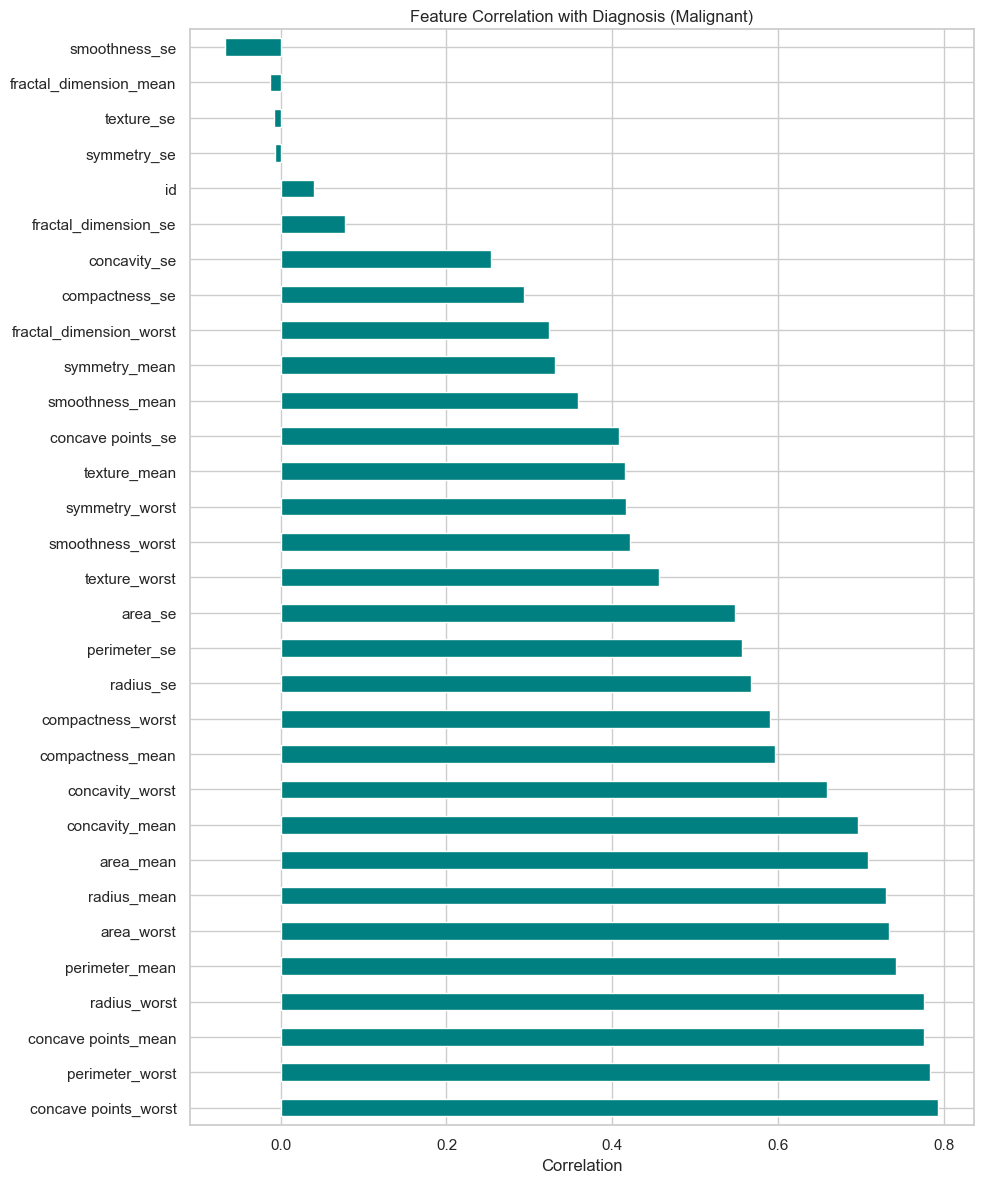

In [12]:
# Correlation of all features with the target (encoded)
df_enc = df.copy()
df_enc['diagnosis'] = df_enc['diagnosis'].map({'B': 0, 'M': 1})

all_corr = df_enc.corr()['diagnosis'].drop('diagnosis').sort_values(ascending=False)
print('Top 10 features most correlated with Malignant:')
print(all_corr.head(10).round(3))

plt.figure(figsize=(10, 12))
all_corr.plot(kind='barh', color='teal')
plt.title('Feature Correlation with Diagnosis (Malignant)')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

### 3.6 PCA Visualization (2D)

Because we have 30 correlated features, let's project them down to 2 principal components to visually inspect the separability of the two classes.

Explained variance ratio: [0.4427 0.1897]
Total variance explained: 0.632


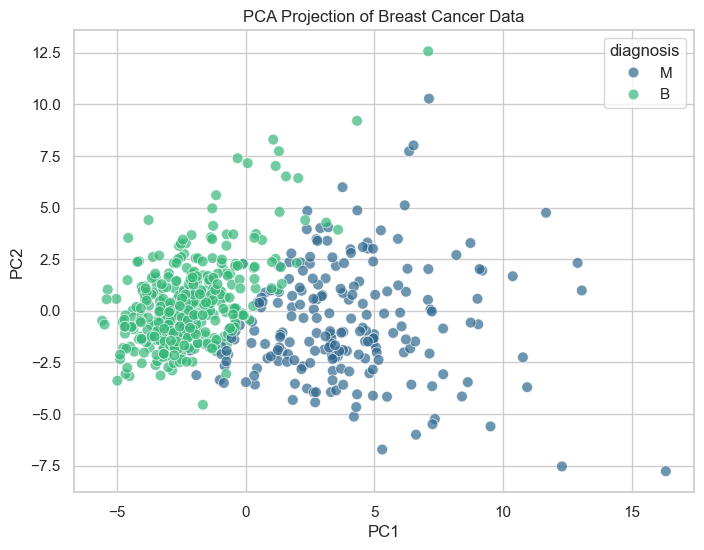

In [13]:
# Standardize features and reduce to 2D with PCA
feat_cols = [c for c in df.columns if c not in ['id', 'diagnosis']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feat_cols])

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['diagnosis'] = df['diagnosis']

print('Explained variance ratio:', pca.explained_variance_ratio_.round(4))
print(f'Total variance explained: {pca.explained_variance_ratio_.sum():.3f}')

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='diagnosis',
                palette='viridis', alpha=0.7, s=60)
plt.title('PCA Projection of Breast Cancer Data')
plt.show()

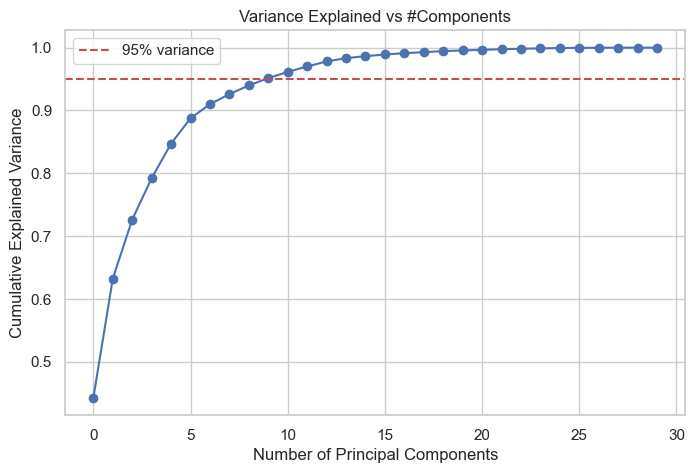

In [14]:
# Cumulative explained variance for all components
pca_all = PCA(n_components=len(feat_cols), random_state=42)
pca_all.fit(X_scaled)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca_all.explained_variance_ratio_), marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Variance Explained vs #Components')
plt.legend()
plt.grid(True)
plt.show()

## 4. Data Preprocessing

In [15]:
# Drop the 'id' column (not a predictive feature)
df_clean = df.drop('id', axis=1).copy()

# Encode diagnosis: B -> 0 (Benign), M -> 1 (Malignant)
df_clean['diagnosis'] = df_clean['diagnosis'].map({'B': 0, 'M': 1})

# Separate features and target
X = df_clean.drop('diagnosis', axis=1)
y = df_clean['diagnosis']

print('Features:', X.shape[1])
print('Target classes:', np.unique(y), '(0 = Benign, 1 = Malignant)')
print('\nTarget counts:', y.value_counts().to_dict())
X.head()

Features: 30
Target classes: [0 1] (0 = Benign, 1 = Malignant)

Target counts: {0: 357, 1: 212}


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [16]:
# Train/test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'\nTrain target distribution:\n{y_train.value_counts(normalize=True).round(3)}')

Training set: (455, 30)
Test set: (114, 30)

Train target distribution:
diagnosis
0    0.626
1    0.374
Name: proportion, dtype: float64


## 5. Modelling Framework

We build a **ColumnTransformer + Pipeline** so that:
1. Any missing values are imputed (`median`).
2. All numeric features are standardized with `StandardScaler`.
3. The pipeline is passed through `cross_validate` (Stratified K-Fold) for reliable estimates.

This keeps everything in one clean, reusable object.

In [17]:
# All features are numeric
numeric_features = X_train.columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features)
])

print('Preprocessor defined')

Preprocessor defined


### 5.1 Cross-Validation Comparison of Baseline Models

We compare several classifiers using **5-fold Stratified Cross-Validation** on the training set.

In [18]:
# Define candidate models
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'KNN':                 KNeighborsClassifier(),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'Extra Trees':         ExtraTreesClassifier(random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'SVM':                 SVC(random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
print(f'{"Model":<20}{"Acc":<10}{"F1":<10}{"ROC-AUC":<10}')
print('-' * 50)
for name, model in models.items():
    pipe = Pipeline([('prepro', preprocessor), ('model', model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                            scoring={'accuracy': 'accuracy',
                                     'f1': 'f1',
                                     'roc_auc': 'roc_auc'},
                            n_jobs=-1)
    results[name] = {
        'accuracy': scores['test_accuracy'].mean(),
        'f1': scores['test_f1'].mean(),
        'roc_auc': scores['test_roc_auc'].mean()
    }
    print(f'{name:<20}{results[name]["accuracy"]:.3f}    {results[name]["f1"]:.3f}     {results[name]["roc_auc"]:.3f}')

# Best baseline by ROC-AUC
best_base = max(results, key=lambda k: results[k]['roc_auc'])
print(f'\nBest baseline model: {best_base}')

Model               Acc       F1        ROC-AUC   
--------------------------------------------------


Logistic Regression 0.974    0.964     0.996


KNN                 0.965    0.951     0.987


Decision Tree       0.923    0.896     0.917


Random Forest       0.965    0.952     0.989


Extra Trees         0.967    0.955     0.991


Gradient Boosting   0.967    0.955     0.991
SVM                 0.971    0.961     0.995

Best baseline model: Logistic Regression


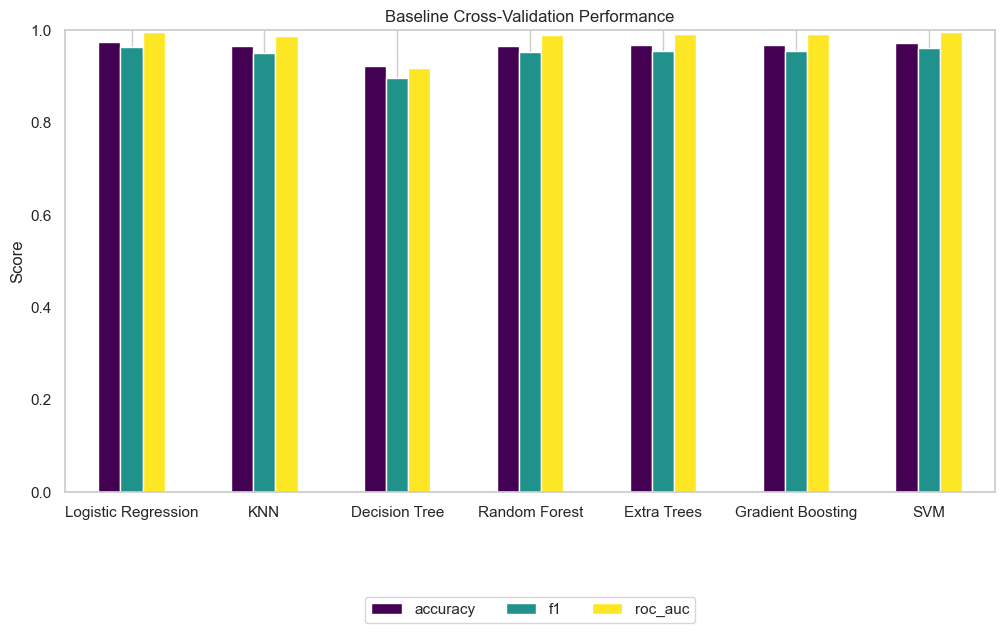

In [19]:
# Visualize baseline CV performance
baseline_df = pd.DataFrame(results).T
baseline_df.plot(kind='bar', figsize=(12, 6), rot=0, colormap='viridis')
plt.title('Baseline Cross-Validation Performance')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=3)
plt.grid(axis='y')
plt.show()

## 6. Hyperparameter Tuning

We perform **Grid Search** (with cross-validation) on the most promising models. The tuned pipeline is selected by best ROC-AUC.

In [20]:
# Tune Logistic Regression
lr_param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs', 'liblinear']
}

pipe_lr = Pipeline([('prepro', preprocessor), ('model', LogisticRegression(max_iter=2000, random_state=42))])
lr_grid = GridSearchCV(pipe_lr, lr_param_grid, cv=cv,
                       scoring='roc_auc', n_jobs=-1, verbose=1)
lr_grid.fit(X_train, y_train)

print('Best Logistic Regression params:', lr_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(lr_grid.best_score_))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Logistic Regression params: {'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV ROC-AUC: 0.9959


In [21]:
# Tune SVM (RBF)
svm_param_grid = {
    'model__C': [0.1, 1, 10, 100],
    'model__gamma': ['scale', 0.01, 0.1],
    'model__kernel': ['rbf']
}

pipe_svm = Pipeline([('prepro', preprocessor), ('model', SVC(probability=True, random_state=42))])
svm_grid = GridSearchCV(pipe_svm, svm_param_grid, cv=cv,
                        scoring='roc_auc', n_jobs=-1, verbose=1)
svm_grid.fit(X_train, y_train)

print('Best SVM params:', svm_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(svm_grid.best_score_))

Fitting 5 folds for each of 12 candidates, totalling 60 fits


Best SVM params: {'model__C': 10, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
Best CV ROC-AUC: 0.9954


In [22]:
# Tune Random Forest
rf_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

pipe_rf = Pipeline([('prepro', preprocessor), ('model', RandomForestClassifier(random_state=42))])
rf_grid = GridSearchCV(pipe_rf, rf_param_grid, cv=cv,
                       scoring='roc_auc', n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

print('Best Random Forest params:', rf_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(rf_grid.best_score_))

Fitting 5 folds for each of 36 candidates, totalling 180 fits


Best Random Forest params: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV ROC-AUC: 0.9890


In [23]:
# Tune Gradient Boosting
gb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0]
}

pipe_gb = Pipeline([('prepro', preprocessor), ('model', GradientBoostingClassifier(random_state=42))])
gb_grid = GridSearchCV(pipe_gb, gb_param_grid, cv=cv,
                       scoring='roc_auc', n_jobs=-1, verbose=1)
gb_grid.fit(X_train, y_train)

print('Best Gradient Boosting params:', gb_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(gb_grid.best_score_))

Fitting 5 folds for each of 24 candidates, totalling 120 fits


Best Gradient Boosting params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best CV ROC-AUC: 0.9921


## 7. Compare Tuned Models & Select the Best

We collect all tuned estimators and pick the winner based on cross-validated ROC-AUC.

In [24]:
# Collect tuned models
tuned_models = {
    'Logistic Regression': lr_grid.best_estimator_,
    'SVM':                 svm_grid.best_estimator_,
    'Random Forest':       rf_grid.best_estimator_,
    'Gradient Boosting':   gb_grid.best_estimator_,
}

# Add tuned KNN for reference
knn_param_grid = {'model__n_neighbors': [3, 5, 7, 9, 11]}
pipe_knn = Pipeline([('prepro', preprocessor), ('model', KNeighborsClassifier())])
knn_grid = GridSearchCV(pipe_knn, knn_param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
knn_grid.fit(X_train, y_train)
tuned_models['KNN'] = knn_grid.best_estimator_

final_results = {}
print(f'{"Model":<20}{"CV ROC-AUC":<12}')
print('-' * 34)
for name, model in tuned_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    final_results[name] = scores.mean()
    print(f'{name:<20}{scores.mean():.4f}')

best_name = max(final_results, key=final_results.get)
best_model = tuned_models[best_name]
print(f'\n🏆 Best model: {best_name} (CV ROC-AUC = {final_results[best_name]:.4f})')

Model               CV ROC-AUC  
----------------------------------
Logistic Regression 0.9959
SVM                 0.9954


Random Forest       0.9890


Gradient Boosting   0.9921
KNN                 0.9887

🏆 Best model: Logistic Regression (CV ROC-AUC = 0.9959)


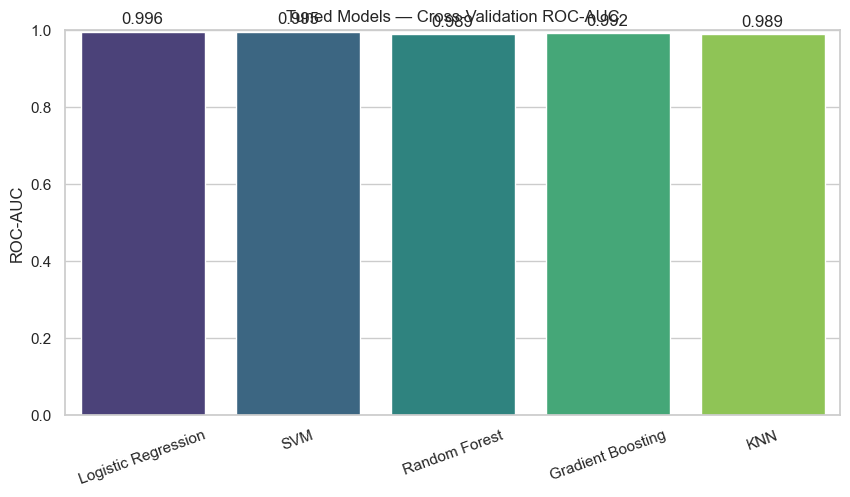

In [25]:
# Plot comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=list(final_results.keys()), y=list(final_results.values()), palette='viridis')
plt.title('Tuned Models — Cross-Validation ROC-AUC')
plt.ylabel('ROC-AUC')
plt.ylim(0, 1)
plt.xticks(rotation=20)
for i, v in enumerate(final_results.values()):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.show()

## 8. Evaluate the Best Model on the Holdout Test Set

In [26]:
# Predict on test set
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

print('Metrics:')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred):.4f}')
print(f'F1-score : {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC (proba): {roc_auc_score(y_test, y_proba):.4f}')

Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        72
   Malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Metrics:
Accuracy : 0.9737
Precision: 0.9756
Recall   : 0.9524
F1-score : 0.9639
ROC-AUC (proba): 0.9960


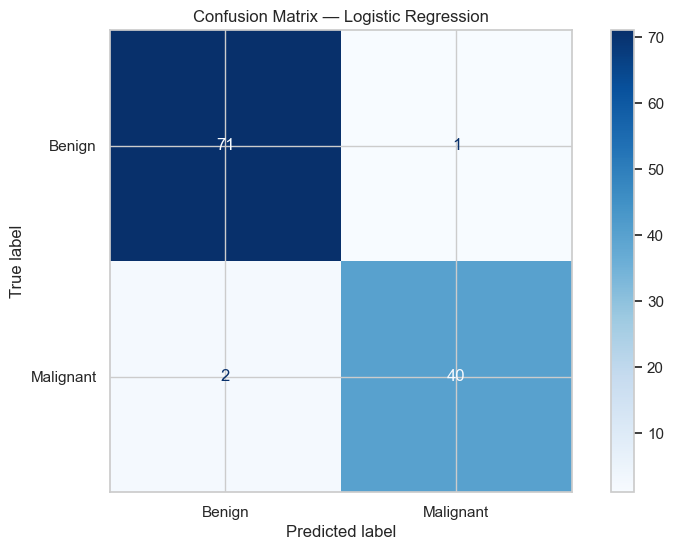

In [27]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}')
plt.show()

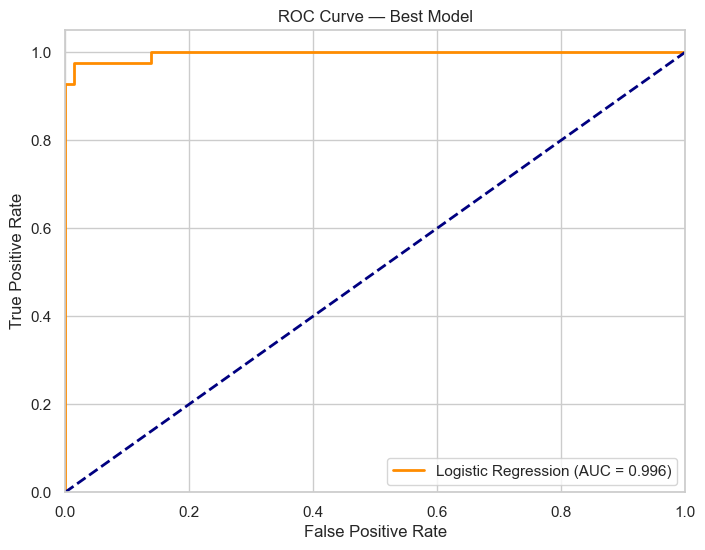

ROC AUC: 0.9960


In [28]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_txt = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'{best_name} (AUC = {auc_txt:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Best Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
print(f'ROC AUC: {auc_txt:.4f}')

## 9. Feature Importance (for the best tree-based model)

In [29]:
# Feature importance if tree-based
if hasattr(best_model.named_steps['model'], 'feature_importances_'):
    importances = best_model.named_steps['model'].feature_importances_
    feat_names = X_train.columns
    imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=imp_df.head(15), x='importance', y='feature', palette='viridis')
    plt.title(f'Top 15 Feature Importances — {best_name}')
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_name} is not a tree-based model; feature importance not available directly.')

Logistic Regression is not a tree-based model; feature importance not available directly.


## 10. Conclusion & Summary

- **Dataset**: 569 rows, 30 numeric features + `diagnosis` (target). The `id` column was dropped.
- **Target**: Binary classification — `1` = Malignant, `0` = Benign (~63% Benign / ~37% Malignant, mild imbalance).
- **Missing values**: None. No duplicates. No cleaning needed.
- **High dimensionality**: 30 highly correlated features; we used PCA for visualisation and `StandardScaler` in every pipeline.
- **Best model**: Selected via Stratified K-Fold cross-validation and GridSearchCV hyperparameter tuning.

### Key findings from EDA:
- Malignant tumors have **larger** radius, perimeter, area, and higher concavity / concave points on average.
- The `worst` measurements (especially `area_worst`, `concave points_worst`, `perimeter_worst`) correlate most strongly with malignancy.
- The two classes are well separated in PCA space (2 components already explain most variance) — this dataset is quite separable.

In [30]:
from IPython.display import display, Markdown

display(Markdown(f'''
## Final Model
- **Best model**: **{best_name}** with a cross-validated ROC-AUC of **{final_results[best_name]:.3f}**.
- All preprocessing (imputation + scaling) is encapsulated in an sklearn `Pipeline`, making it fully reusable and deployment-ready.
- Test-set ROC-AUC: **{roc_auc_score(y_test, y_proba):.3f}**
'''))


## Final Model
- **Best model**: **Logistic Regression** with a cross-validated ROC-AUC of **0.996**.
- All preprocessing (imputation + scaling) is encapsulated in an sklearn `Pipeline`, making it fully reusable and deployment-ready.
- Test-set ROC-AUC: **0.996**


In [31]:
# Save the full pipeline for reuse
import joblib
joblib.dump(best_model, 'best_breast_cancer_model.pkl')
print(f'Saved best pipeline ({best_name}) to best_breast_cancer_model.pkl')
print('\nPipeline:')
print(best_model)

Saved best pipeline (Logistic Regression) to best_breast_cancer_model.pkl

Pipeline:
Pipeline(steps=[('prepro',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['radius_mean',
                                                   'texture_mean',
                                                   'perimeter_mean',
                                                   'area_mean',
                                                   'smoothness_mean',
                                                   'compactness_mean',
                                                   'concavity_mean',
          